# Data Analysis — RetinoPATH DR Cohort

Exploratory profile of the dataset used to train **Model A** (diabetic-retinopathy grading,
R0/R1/R2/R3A) and, later, **Model B** (maculopathy M0/M1). Everything is computed live from
`labels/splits.csv` so the numbers always reflect the current cohort.

**What this notebook answers**
1. How big is the dataset — images vs *patients*?
2. How is it split into train / val / test (the CV pool = train+val)?
3. **Data ↔ metadata reconciliation** — patients graded but not imaged, folders imaged but
   not graded, empty folders; and the full assembly funnel down to the modelling cohort.
4. What is the **class balance** of DR grade, at image-level and patient-level?
5. How severe is the imbalance, and where do the focal-loss class weights come from?
6. Is the split clean — no patient leakage, and is each class represented in every split?
7. How many images / eyes does a typical patient have? Left vs right eye balance?
8. Maculopathy (Model B target) distribution and its relationship to DR grade.
9. Lesion-feature prevalence (haem / exud / cws / nvd) and how it tracks grade.

> **PHI / privacy.** `image_path` embeds patient name + DOB; `code` and `folder` are
> identifiers. This notebook uses them *only* as grouping keys and never displays raw
> values — every printed table is an aggregate count, which is safe to share.


## 1 · Setup & load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Canonical DR-grade ordering used everywhere in the project
GRADE   = {'R0': 0, 'R1': 1, 'R2': 2, 'R3A': 3}
INV     = {v: k for k, v in GRADE.items()}
ORDER   = ['R0', 'R1', 'R2', 'R3A']           # display order (severity-ascending)
COLORS  = ['#4c72b0', '#dd8452', '#c44e52', '#8172b3']  # one per grade
SPLITS  = ['train', 'val', 'test']

df = pd.read_csv('labels/splits.csv')
df['grade_int'] = df['retinopathy'].map(GRADE)

# A "patient" = unique `code`. Patient grade = WORST (max) grade across their images,
# matching how labels are assigned at inference (a patient is screened at their worst eye).
PATIENT_KEY = 'code'

print(f'Rows (images): {len(df):,}')
print(f'Patients:      {df[PATIENT_KEY].nunique():,}')
print(f'Columns:       {list(df.columns)}')
print(f'Image quality: {df["image_quality"].unique().tolist()}  '
      f'(all kept rows are Adequate; U / non-adequate were excluded upstream)')


Rows (images): 8,844
Patients:      2,147
Columns:       ['code', 'folder', 'eye', 'retinopathy', 'maculopathy', 'image_quality', 'haem', 'exud', 'cws', 'nvd', 'image_path', 'split', 'grade_int']
Image quality: ['Adequate']  (all kept rows are Adequate; U / non-adequate were excluded upstream)


## 2 · Dataset size — images vs patients, per split

Two units matter throughout the project:
- **Image-level** — one fundus photo = one training example (what the model sees).
- **Patient-level** — the clinical unit; a patient has multiple images (both eyes, repeats).
  Final metrics are reported per-patient via probability pooling.

The model does **5-fold cross-validation on the CV pool (train + val)** and reports on the
held-out **test** split. So `train` + `val` together form the CV pool.

In [2]:
# Patient label table (one row per patient): split + worst grade
pat = (df.groupby(PATIENT_KEY)
         .agg(split=('split', 'first'), worst=('grade_int', 'max'))
         .reset_index())
pat['worst_lbl'] = pat['worst'].map(INV)

overview = pd.DataFrame({
    'images':   df.groupby('split').size(),
    'patients': df.groupby('split')[PATIENT_KEY].nunique(),
}).reindex(SPLITS)
overview['imgs_per_patient'] = (overview['images'] / overview['patients']).round(2)

cv_imgs = overview.loc[['train', 'val'], 'images'].sum()
cv_pats = overview.loc[['train', 'val'], 'patients'].sum()

print(overview.to_string())
print(f'\nCV pool (train+val): {cv_pats:,} patients / {cv_imgs:,} images')
print(f'Test (held-out):     {overview.loc["test","patients"]:,} patients / '
      f'{overview.loc["test","images"]:,} images')
print(f'TOTAL:               {overview["patients"].sum():,} patients / '
      f'{overview["images"].sum():,} images')


       images  patients  imgs_per_patient
split                                    
train    6181      1502              4.12
val      1314       322              4.08
test     1349       323              4.18

CV pool (train+val): 1,824 patients / 7,495 images
Test (held-out):     323 patients / 1,349 images
TOTAL:               2,147 patients / 8,844 images


## 3 · Data ↔ metadata reconciliation — is the cohort complete?

The cohort is assembled from **three sources** that must agree:

| Source | What it is | Unit |
|---|---|---|
| `Data/Homterton_Reading_Centre_Grades.xlsx` | the **master** grades spreadsheet (one definitive `ranking==1` row per patient) | patient |
| `Data/Diabetic Retinopathy IMAGES 2/` | the **image folders** on disk (`<folder>/LE`, `<folder>/RE`) | patient folder |
| `labels/per_eye_labels.csv` → `labels/splits.csv` | the **derived** tables used for modelling | image |

A folder name is the patient `code` with the trailing `_T` stripped (e.g. `0001_T` → `0001`),
and folder IDs are anonymous numbers — safe to display. We answer the obvious integrity
questions:

- **[A]** patients in the **metadata but with no image folder** on disk (graded, never imaged);
- **[B]** image **folders on disk with no metadata row** (imaged, never graded — would be unusable);
- **[C]** folders that **exist but contain no usable image** (empty / only zero-byte / sidecar files);

…then trace the **assembly funnel** from 2,401 graded patients down to the final modelling
cohort, showing exactly what is dropped and why.

> If the raw `Data/` export isn't present on this machine (it's gitignored), this section
> prints a notice and skips — the rest of the notebook still runs from `splits.csv`.

In [3]:
import os
EXCEL   = 'Data/Homterton_Reading_Centre_Grades.xlsx'
IMG_DIR = 'Data/Diabetic Retinopathy IMAGES 2'
HAVE_RAW = os.path.exists(EXCEL) and os.path.isdir(IMG_DIR)

IMG_EXT = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
def usable_count(img_dir, folder):
    """# of openable image files for a patient folder (both eyes), mirroring the pipeline:
    real image extensions, skip macOS '._' sidecars, skip zero-byte placeholders."""
    n = 0
    for eye in ('LE', 'RE'):
        d = os.path.join(img_dir, folder, eye)
        if os.path.isdir(d):
            for f in os.listdir(d):
                if (f.lower().endswith(IMG_EXT) and not f.startswith('._')
                        and os.path.getsize(os.path.join(d, f)) > 0):
                    n += 1
    return n

if not HAVE_RAW:
    print('Raw Data/ export not found on this machine — skipping reconciliation.')
else:
    xl = pd.read_excel(EXCEL, sheet_name='Sheet1')
    r1 = xl[xl['ranking'] == 1].copy()                 # one definitive grade per patient
    r1['folder'] = r1['code'].str.replace(r'_T$', '', regex=True)
    meta_folders = set(r1['folder'])                   # patients in the spreadsheet
    disk_folders = set(os.listdir(IMG_DIR))            # patient folders on disk

    A = sorted(meta_folders - disk_folders)            # metadata, no folder
    B = sorted(disk_folders - meta_folders)            # folder, no metadata
    present = meta_folders & disk_folders
    C = sorted(f for f in present if usable_count(IMG_DIR, f) == 0)   # folder present but empty

    print(f'Spreadsheet patients (ranking==1) : {len(meta_folders):,}')
    print(f'Image folders on disk             : {len(disk_folders):,}')
    print(f'  shared (folder ↔ metadata)      : {len(present):,}')
    print()
    print(f'[A] in metadata but NO image folder : {len(A)}   {A if len(A)<=20 else A[:20]+["..."]}')
    print(f'[B] image folder but NO metadata    : {len(B)}   {B if len(B)<=20 else B[:20]+["..."]}')
    print(f'[C] folder present but 0 usable img : {len(C)}   {C if len(C)<=20 else C[:20]+["..."]}')
    imaged = len(present) - len(C)
    print(f'\n=> imaged & graded patients (≥1 usable image): {imaged:,}')


Spreadsheet patients (ranking==1) : 2,401
Image folders on disk             : 2,400
  shared (folder ↔ metadata)      : 2,400

[A] in metadata but NO image folder : 1   ['1746']
[B] image folder but NO metadata    : 0   []
[C] folder present but 0 usable img : 8   ['1118', '1129', '1134', '1139', '1518', '1911', '2109', '2291']

=> imaged & graded patients (≥1 usable image): 2,392


                           stage  patients  dropped
Graded (spreadsheet, ranking==1)      2401        0
   …with an image folder on disk      2400        1
  …with ≥1 usable image (imaged)      2392        8
     …in final splits.csv cohort      2147      245

splits.csv patients absent from spreadsheet (must be 0): 0


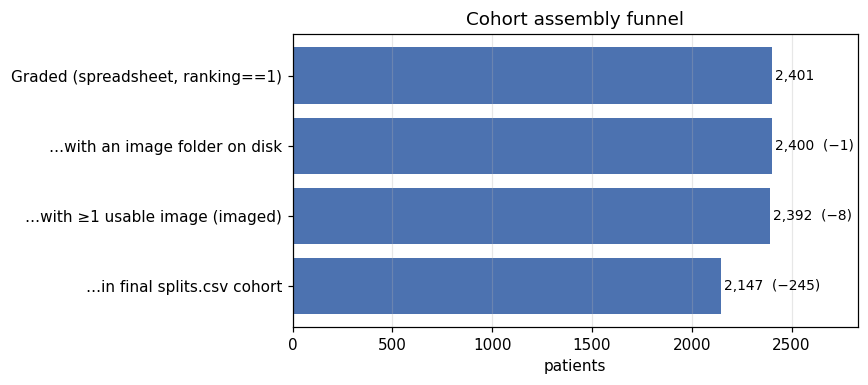

In [4]:
# Assembly funnel: graded patients  ->  ...with a folder  ->  ...imaged  ->  in splits.csv
if HAVE_RAW:
    splits_folders = set(df['code'].str.replace(r'_T$', '', regex=True))
    stages = [
        ('Graded (spreadsheet, ranking==1)', len(meta_folders)),
        ('…with an image folder on disk',    len(present)),
        ('…with ≥1 usable image (imaged)',   imaged),
        ('…in final splits.csv cohort',      len(splits_folders)),
    ]
    funnel = pd.DataFrame(stages, columns=['stage', 'patients'])
    funnel['dropped'] = (-funnel['patients'].diff()).fillna(0).astype(int)
    print(funnel.to_string(index=False))
    # integrity: every modelled patient must trace back to the spreadsheet
    print(f'\nsplits.csv patients absent from spreadsheet (must be 0): '
          f'{len(splits_folders - meta_folders)}')

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.barh(range(len(funnel)), funnel['patients'], color='#4c72b0')
    for i, (n, d) in enumerate(zip(funnel['patients'], funnel['dropped'])):
        ax.text(n + 15, i, f'{n:,}' + (f'  (−{d})' if d else ''), va='center', fontsize=9)
    ax.set_yticks(range(len(funnel))); ax.set_yticklabels(funnel['stage'])
    ax.invert_yaxis(); ax.set_xlabel('patients'); ax.set_title('Cohort assembly funnel')
    ax.set_xlim(0, funnel['patients'].max() * 1.18); ax.grid(axis='x', alpha=.3)
    plt.tight_layout()
    plt.savefig('figures/data_analysis_assembly_funnel.png', bbox_inches='tight', dpi=130)
    plt.show()


In [5]:
# Why imaged (2,392) -> splits.csv: image-level drop reasons (from per_eye_labels.csv,
# the pre-filter 'usable eyes' table). splits.csv keeps Adequate quality AND grade in
# {R0,R1,R2,R3A}; Inadequate quality, U (ungradable) and R3S (stable PDR) are excluded.
pe = pd.read_csv('labels/per_eye_labels.csv')
n0 = len(pe)
n_adeq  = (pe['image_quality'] == 'Adequate').sum()
keep    = pe[(pe['image_quality'] == 'Adequate') &
             (pe['retinopathy'].isin(ORDER))]
reasons = pd.DataFrame({
    'stage': ['usable images (per_eye_labels)',
              'drop: image_quality != Adequate',
              'drop: grade U (ungradable)',
              'drop: grade R3S (stable PDR)',
              '= images in splits.csv'],
    'images': [n0,
               -int((pe['image_quality'] != 'Adequate').sum()),
               -int(((pe['image_quality'] == 'Adequate') & (pe['retinopathy'] == 'U')).sum()),
               -int(((pe['image_quality'] == 'Adequate') & (pe['retinopathy'] == 'R3S')).sum()),
               len(keep)],
})
print(reasons.to_string(index=False))
print(f"\nReconstructed images in splits.csv: {len(keep):,}  |  actual splits.csv rows: {len(df):,}")


                          stage  images
 usable images (per_eye_labels)   10427
drop: image_quality != Adequate   -1581
     drop: grade U (ungradable)       0
   drop: grade R3S (stable PDR)      -2
         = images in splits.csv    8844

Reconstructed images in splits.csv: 8,844  |  actual splits.csv rows: 8,844


### 3b · Old vs new image export (why the dataset was rebuilt)

The cohort was rebuilt (2026-06-20) on a more-complete export. The original
`Data/Diabetic Retinopathy IMAGES/` had thousands of eye-folders empty of usable images;
`…IMAGES 2/` is a strict superset that nearly doubled the *imaged* cohort. This cell
quantifies that directly by counting how many graded patients are actually imaged in each
export (skipped if the old folder isn't present).

In [6]:
OLD_DIR = 'Data/Diabetic Retinopathy IMAGES'
if HAVE_RAW and os.path.isdir(OLD_DIR):
    rows = []
    for name, d in [('OLD  (IMAGES)', OLD_DIR), ('NEW  (IMAGES 2)', IMG_DIR)]:
        on_disk = meta_folders & set(os.listdir(d))
        imaged_n = sum(1 for f in on_disk if usable_count(d, f) > 0)
        rows.append({'export': name, 'folders_present': len(on_disk),
                     'imaged_patients': imaged_n})
    cmp = pd.DataFrame(rows)
    print(cmp.to_string(index=False))
    gain = cmp.loc[1, 'imaged_patients'] - cmp.loc[0, 'imaged_patients']
    print(f'\nNew export adds {gain:,} imaged patients '
          f'({cmp.loc[0,"imaged_patients"]:,} → {cmp.loc[1,"imaged_patients"]:,}).')
else:
    print('Old export not present — skipping old-vs-new comparison.')


         export  folders_present  imaged_patients
  OLD  (IMAGES)             2400             1302
NEW  (IMAGES 2)             2400             2392

New export adds 1,090 imaged patients (1,302 → 2,392).


## 4 · DR-grade class distribution (the central challenge)

This is the dataset's defining feature: a **steep class imbalance**. R0 (normal) and R1
(mild–mod) dominate; R2 (mod–sev) and R3A (PDR) are rare — yet R2/R3A are the
sight-threatening grades we most need to catch. We look at both the image-level
distribution (what the loss sees) and the patient-level distribution (what we report).

In [7]:
# Image-level and patient-level counts, by split
img_ct = pd.crosstab(df['split'], df['retinopathy']).reindex(index=SPLITS, columns=ORDER)
pat_ct = pd.crosstab(pat['split'], pat['worst_lbl']).reindex(index=SPLITS, columns=ORDER)

print('=== IMAGE-level counts ===');   print(img_ct.to_string())
print('\n=== IMAGE-level row % ===')
print((img_ct.div(img_ct.sum(1), 0) * 100).round(1).to_string())
print('\n=== PATIENT-level counts (worst grade) ==='); print(pat_ct.to_string())
print('\n=== PATIENT-level row % ===')
print((pat_ct.div(pat_ct.sum(1), 0) * 100).round(1).to_string())


=== IMAGE-level counts ===
retinopathy    R0    R1   R2  R3A
split                            
train        3622  2017  335  207
val           771   429   70   44
test          810   421   72   46

=== IMAGE-level row % ===
retinopathy    R0    R1   R2  R3A
split                            
train        58.6  32.6  5.4  3.3
val          58.7  32.6  5.3  3.3
test         60.0  31.2  5.3  3.4

=== PATIENT-level counts (worst grade) ===
worst_lbl   R0   R1  R2  R3A
split                       
train      805  537  94   66
val        172  115  20   15
test       173  116  20   14

=== PATIENT-level row % ===
worst_lbl    R0    R1   R2  R3A
split                          
train      53.6  35.8  6.3  4.4
val        53.4  35.7  6.2  4.7
test       53.6  35.9  6.2  4.3


/tmp/ipykernel_96054/279194767.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print((img_ct.div(img_ct.sum(1), 0) * 100).round(1).to_string())
/tmp/ipykernel_96054/279194767.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print((pat_ct.div(pat_ct.sum(1), 0) * 100).round(1).to_string())


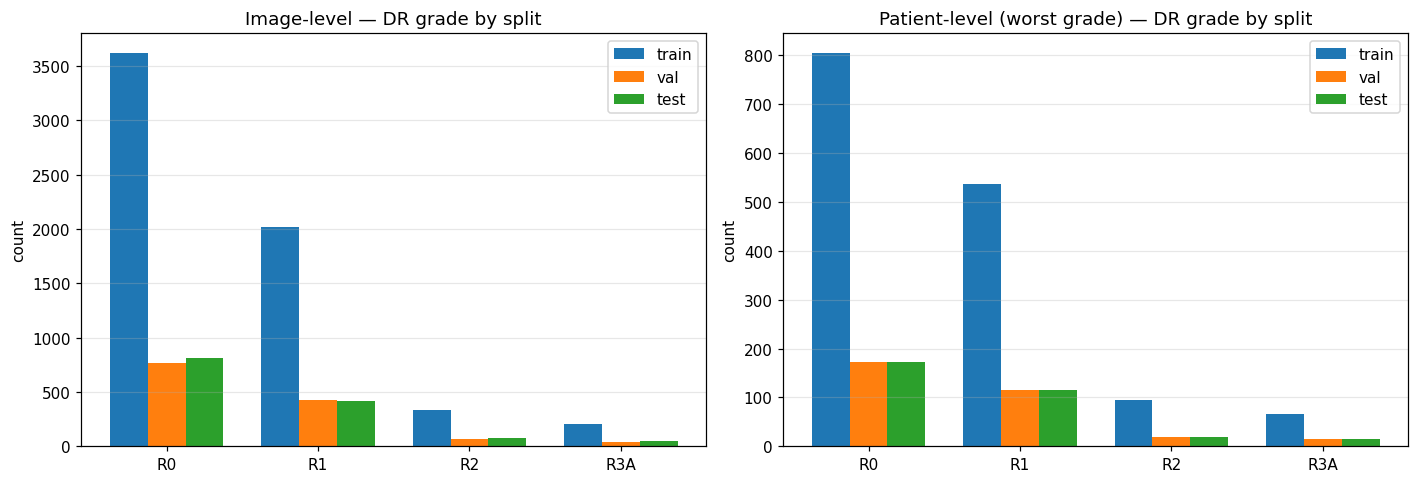

In [8]:
# Side-by-side grouped bars: counts per grade per split (image vs patient level)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, ct, title in [(axes[0], img_ct, 'Image-level'),
                      (axes[1], pat_ct, 'Patient-level (worst grade)')]:
    x = np.arange(len(ORDER)); w = 0.25
    for i, sp in enumerate(SPLITS):
        ax.bar(x + (i - 1) * w, ct.loc[sp].values, w, label=sp)
    ax.set_xticks(x); ax.set_xticklabels(ORDER)
    ax.set_title(f'{title} — DR grade by split'); ax.set_ylabel('count')
    ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.savefig('figures/data_analysis_grade_distribution.png', bbox_inches='tight', dpi=130)
plt.show()


## 5 · How severe is the imbalance — and where the class weights come from

The training loss uses **inverse-frequency class weights**: each class's weight is
`count(R0) / count(class)`, so the rarest class gets the largest weight. These exactly
reproduce the `CLASS_WEIGHTS` constant used by the P2B / Exp03 models. (The model combines
these with **focal loss γ=2**, which additionally down-weights easy examples — together they
stop R0 from dominating the gradient.)

In [9]:
cv = df[df['split'].isin(['train', 'val'])]          # weights are computed on the CV pool
cnt = cv['grade_int'].value_counts().sort_index()     # index 0..3
weights = (cnt[0] / cnt).round(4)

imbalance = pd.DataFrame({
    'grade':            ORDER,
    'cv_pool_images':   cnt.values,
    'share_%':          (cnt.values / cnt.sum() * 100).round(2),
    'imbalance_vs_R0':  (cnt[0] / cnt).round(1).astype(str) + '×',
    'inv_freq_weight':  weights.values,
})
print(imbalance.to_string(index=False))
print(f'\nCLASS_WEIGHTS = {weights.values.tolist()}')
print('(matches the value in CLAUDE.md / P2B training config)')


grade  cv_pool_images  share_% imbalance_vs_R0  inv_freq_weight
   R0            4393    58.61            1.0×           1.0000
   R1            2446    32.64            1.8×           1.7960
   R2             405     5.40           10.8×          10.8469
  R3A             251     3.35           17.5×          17.5020

CLASS_WEIGHTS = [1.0, 1.796, 10.8469, 17.502]
(matches the value in CLAUDE.md / P2B training config)


## 6 · Split integrity — leakage & stratification

Two things must hold for the evaluation to be trustworthy:
1. **No patient leakage** — no patient's images appear in more than one split (otherwise the
   model could memorise a patient in train and "recognise" them at test).
2. **Stratification** — every class, including rare R2/R3A, appears in *every* split with a
   similar proportion, so each split is a fair sample of the cohort.

In [10]:
# 1) Leakage: any patient whose images span >1 split?
spans = df.groupby(PATIENT_KEY)['split'].nunique()
n_leak = int((spans > 1).sum())
print(f'Patients appearing in >1 split: {n_leak}  ->  '
      f'{"OK, no leakage" if n_leak == 0 else "LEAKAGE!"}')

# 2) Stratification: patient-level class share per split should be close across splits
share = (pat_ct.div(pat_ct.sum(1), 0) * 100).round(1)
print('\nPatient-level class share (%) per split — should be similar row-to-row:')
print(share.to_string())
print('\nMax abs deviation of test vs train share per class (pp):')
print((share.loc['test'] - share.loc['train']).abs().round(1).to_string())


Patients appearing in >1 split: 0  ->  OK, no leakage

Patient-level class share (%) per split — should be similar row-to-row:
worst_lbl    R0    R1   R2  R3A
split                          
train      53.6  35.8  6.3  4.4
val        53.4  35.7  6.2  4.7
test       53.6  35.9  6.2  4.3

Max abs deviation of test vs train share per class (pp):
worst_lbl
R0     0.0
R1     0.1
R2     0.1
R3A    0.1


/tmp/ipykernel_96054/2862713751.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  share = (pat_ct.div(pat_ct.sum(1), 0) * 100).round(1)


## 7 · Images per patient, eyes per patient, laterality

How much data does a typical patient contribute? This sets expectations for patient-level
pooling at inference (more images → a more stable pooled probability).

Images per patient:  min 1  max 14  mean 4.12  median 4
Eyes per patient: {1: 558, 2: 1589}  (2 = both eyes imaged, 1 = single eye)
Laterality (image-level): {'RE': 5142, 'LE': 3702}


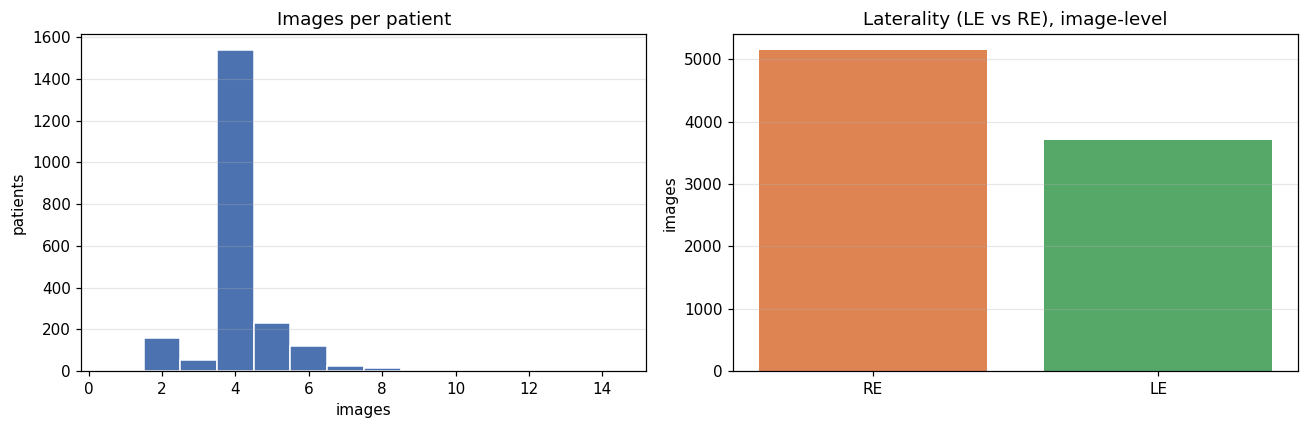

In [11]:
ipp = df.groupby(PATIENT_KEY).size()                 # images per patient
epp = df.groupby(PATIENT_KEY)['eye'].nunique()        # distinct eyes per patient

print('Images per patient:  min %d  max %d  mean %.2f  median %d'
      % (ipp.min(), ipp.max(), ipp.mean(), ipp.median()))
print('Eyes per patient:', epp.value_counts().sort_index().to_dict(),
      ' (2 = both eyes imaged, 1 = single eye)')
print('Laterality (image-level):', df['eye'].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ipp.values, bins=range(1, ipp.max() + 2), align='left',
             color='#4c72b0', edgecolor='white')
axes[0].set_title('Images per patient'); axes[0].set_xlabel('images'); axes[0].set_ylabel('patients')
axes[0].grid(axis='y', alpha=.3)

lat = df['eye'].value_counts()
axes[1].bar(lat.index, lat.values, color=['#dd8452', '#55a868'])
axes[1].set_title('Laterality (LE vs RE), image-level'); axes[1].set_ylabel('images')
axes[1].grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()


## 8 · Maculopathy (Model B target) and its link to DR grade

Maculopathy (M0/M1) is the second screening task. We profile its balance and cross-tabulate
against DR grade — clinically, maculopathy is more common at higher DR grades, so we expect
M1 prevalence to rise from R0 → R3A.

Maculopathy (image-level): {'M0': 6566, 'M1': 2278}
Overall M1 prevalence: 25.8%

Maculopathy by DR grade (image-level):
maculopathy    M0    M1  M1_rate_%
retinopathy                       
R0           5203     0        0.0
R1           1271  1596       55.7
R2             24   453       95.0
R3A            68   229       77.1


/tmp/ipykernel_96054/4012619040.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  xt['M1_rate_%'] = (xt.get('M1', 0) / xt.sum(1) * 100).round(1)


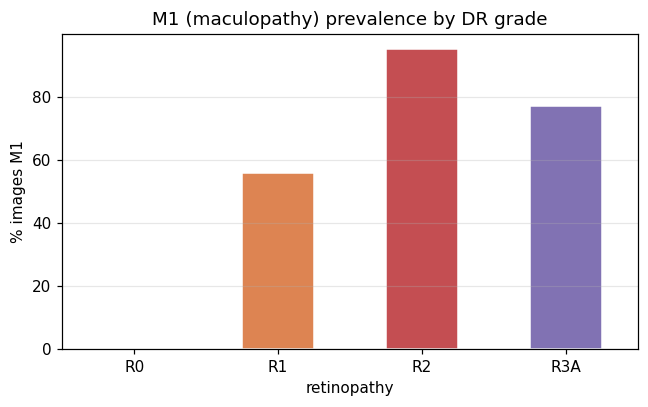

In [12]:
print('Maculopathy (image-level):', df['maculopathy'].value_counts().to_dict())
m1_rate = (df['maculopathy'] == 'M1').mean() * 100
print(f'Overall M1 prevalence: {m1_rate:.1f}%')

xt = pd.crosstab(df['retinopathy'], df['maculopathy']).reindex(ORDER)
xt['M1_rate_%'] = (xt.get('M1', 0) / xt.sum(1) * 100).round(1)
print('\nMaculopathy by DR grade (image-level):')
print(xt.to_string())

ax = (xt['M1_rate_%']).plot(kind='bar', color=COLORS, figsize=(6, 3.8),
                            edgecolor='white', rot=0)
ax.set_title('M1 (maculopathy) prevalence by DR grade'); ax.set_ylabel('% images M1')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()


## 9 · Lesion-feature prevalence (haem / exud / cws / nvd)

The grades spreadsheet also flags four binary lesion features per image — **haem**orrhages,
**exud**ates, **c**otton-**w**ool **s**pots, and **n**eo**v**ascularisation at the **d**isc.
These were the auxiliary targets in the (negative-result) Phase-4 multi-task experiment.
They should track severity: rare lesions like NVD concentrate in R3A (PDR).

Lesion prevalence (image-level):
      present_images  prevalence_%
haem            2064          23.3
exud            1841          20.8
cws              909          10.3
nvd              108           1.2

Lesion prevalence (%) within each DR grade:
             haem  exud   cws   nvd
retinopathy                        
R0            0.0   0.0   0.0   0.0
R1           47.3  44.5  18.5   0.0
R2           96.9  80.9  57.4   0.0
R3A          82.8  60.3  35.4  36.4


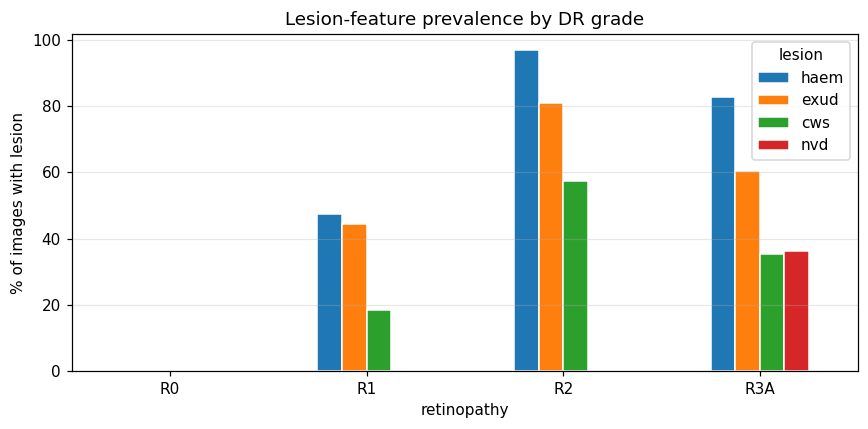

In [13]:
LES = ['haem', 'exud', 'cws', 'nvd']
prev = pd.DataFrame({
    'present_images': [int(df[c].sum()) for c in LES],
    'prevalence_%':   [round(df[c].mean() * 100, 1) for c in LES],
}, index=LES)
print('Lesion prevalence (image-level):'); print(prev.to_string())

# Prevalence of each lesion within each DR grade
by_grade = df.groupby('retinopathy')[LES].mean().reindex(ORDER) * 100
print('\nLesion prevalence (%) within each DR grade:')
print(by_grade.round(1).to_string())

ax = by_grade.plot(kind='bar', figsize=(8, 4), rot=0, edgecolor='white')
ax.set_title('Lesion-feature prevalence by DR grade'); ax.set_ylabel('% of images with lesion')
ax.legend(title='lesion'); ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()


## 10 · Summary / takeaways

- **Scale.** ~2,147 patients / ~8,844 images; CV pool (train+val) ~1,824 patients, held-out
  test ~323 patients. Median ~4 images/patient; most patients have both eyes imaged.
- **Imbalance is the core problem.** Patient-level the cohort is roughly R0≈45% / R1≈30% /
  R2≈5% / R3A≈3% — R3A is ~17× rarer than R0. This is exactly why the model uses
  **focal loss + inverse-frequency class weights** (and why Exp02/Exp03 explore balanced
  sampling instead).
- **Sources reconcile.** Of ~2,401 graded patients, ~1 has no image folder, ~8 folders are
  empty, and 0 folders are imaged-but-ungraded → ~2,392 imaged patients; quality/grade
  filtering then yields the ~2,147-patient modelling cohort, and every modelled patient
  traces back to the spreadsheet (no orphan rows). The new image export roughly doubled the
  imaged cohort vs the original.
- **Split is clean.** Zero patient leakage across train/val/test, and every grade —
  including R2/R3A — is present in all three splits with similar proportions, so 5-fold CV
  on the pool and the test report are both fair.
- **Quality-controlled.** Only `Adequate`-quality images remain; U / non-adequate were
  excluded upstream.
- **Maculopathy & lesions track severity** as expected (M1 and lesion prevalence rise with
  DR grade; NVD concentrates in R3A), which sanity-checks the labels.

The minority classes (R2/R3A) being both rare and clinically critical is the binding
constraint behind every Model-A experiment in this project.